# Connect a network

**What you'll learn / who it's for (simulation).** NEST-like wiring with connection rules, assembled into a small **Brunel (2000) random balanced network** — the canonical sparse E/I network. We use delta synapses (`iaf_psc_delta`), so weights are membrane-voltage jumps in `mV`.

We keep `order` small here so the notebook runs fast; the [example gallery](../../examples/nest-gallery.rst) has full-scale Brunel variants. Ported from `examples/nest_like/brunel_delta.py`.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import brainstate
brainstate.environ.set(precision=64)

import numpy as np
import brainunit as u
import braintools
import matplotlib.pyplot as plt
from brainpy import state as bp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Brunel parameters

The standard Brunel knobs: `g` (relative inhibition), `eta` (external drive relative to threshold), `epsilon` (connection density). `NE`/`NI` are the population sizes and `CE`/`CI` the in-degrees. We pick a small `order` for a quick run.

In [2]:
order = 100                         # small for a fast notebook run
g, eta, epsilon = 5.0, 2.0, 0.1
delay = 1.5                         # ms
NE, NI = 4 * order, 1 * order
CE, CI = int(epsilon * NE), int(epsilon * NI)
N_rec = 50
tauMem, CMem, theta, tref = 20.0, 1.0, 20.0, 2.0

J = 0.1                             # mV, delta postsynaptic jump
J_ex = J
J_in = -g * J_ex
nu_th = theta / (J * CE * tauMem)
p_rate = 1000.0 * (eta * nu_th) * CE   # external Poisson rate (Hz)

## Create populations and the external drive

Two `iaf_psc_delta` populations and a `poisson_generator` background. Each population also gets a `spike_recorder` tapping the first `N_rec` neurons.

In [3]:
npar = dict(C_m=CMem * u.pF, tau_m=tauMem * u.ms, t_ref=tref * u.ms,
            E_L=0. * u.mV, V_reset=0. * u.mV, V_th=theta * u.mV,
            V_initializer=braintools.init.Constant(0. * u.mV))

sim = bp.Simulator(dt=0.1 * u.ms)
ne = sim.create(bp.iaf_psc_delta, NE, params=npar)
ni = sim.create(bp.iaf_psc_delta, NI, params=npar)
noise = sim.create(bp.poisson_generator, rate=p_rate * u.Hz)
esr = sim.create(bp.spike_recorder)
isr = sim.create(bp.spike_recorder)

## Wire the network with connection rules

- The background drives every neuron: `rule=all_to_all`.
- Recurrent excitation and inhibition use `fixed_indegree(K)` — each target draws `K` random presynaptic partners (the Brunel rule). `comm='sparse'` keeps the event communication memory-light; `seed=` makes the draw reproducible.
- `ne + ni` targets the whole network in one call; `ne[:N_rec]` records a sub-sample.

In [4]:
sim.connect(noise, ne, weight=J_ex * u.mV, delay=delay * u.ms, rule=bp.all_to_all)
sim.connect(noise, ni, weight=J_ex * u.mV, delay=delay * u.ms, rule=bp.all_to_all)
sim.connect(ne, ne + ni, weight=J_ex * u.mV, delay=delay * u.ms,
            rule=bp.fixed_indegree(CE), comm='sparse', allow_multapses=True, seed=1)
sim.connect(ni, ne + ni, weight=J_in * u.mV, delay=delay * u.ms,
            rule=bp.fixed_indegree(CI), comm='sparse', allow_multapses=True, seed=2)
sim.connect(ne[:N_rec], esr)
sim.connect(ni[:N_rec], isr)

res = sim.simulate(1000. * u.ms)

## Firing rates and the excitatory raster

excitatory rate: 60.56 spks/s
inhibitory rate: 60.18 spks/s


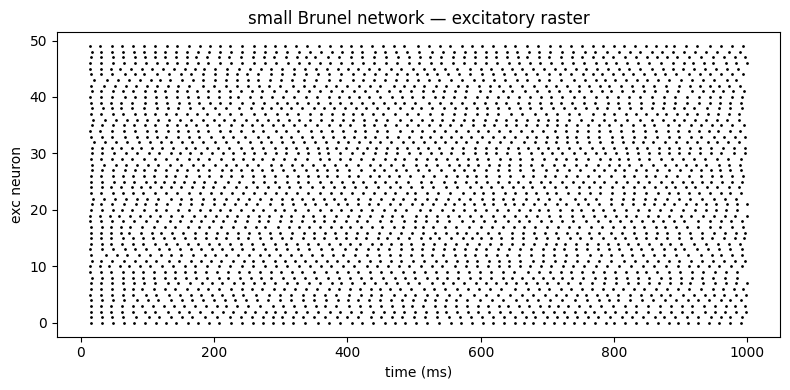

In [5]:
erate = res.rate(esr.segments[0].population)
irate = res.rate(isr.segments[0].population)
print(f'excitatory rate: {erate:.2f} spks/s')
print(f'inhibitory rate: {irate:.2f} spks/s')

spk = np.asarray(res.spikes(esr.segments[0].population))   # (T, N_rec)
ts, ids = np.nonzero(spk > 0)
plt.figure(figsize=(8, 4))
plt.scatter(ts * 0.1, ids, s=1.0, color='k')
plt.xlabel('time (ms)'); plt.ylabel('exc neuron')
plt.title('small Brunel network — excitatory raster')
plt.tight_layout()

## See also

- [Connectivity](../connectivity.rst) — connection rules and the synapse spec.
- [Porting walkthrough](../porting-walkthrough.ipynb) — Brunel side by side with NEST.
- [Example gallery](../../examples/nest-gallery.rst) — full-scale Brunel and other networks.
- [Validation status](../validation-status.rst) — how network parity is asserted (distributional, category D).